In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

# Dataset paths
occupancy = pd.read_csv("dataset/lot_occupancy_hourly.csv")
parking = pd.read_csv("dataset/parking_lots.csv")
reviews = pd.read_csv("dataset/reviews.csv")

print("Occupancy:", occupancy.shape)
print("Parking lots:", parking.shape)
print("Reviews:", reviews.shape)


Occupancy: (4575, 11)
Parking lots: (40, 13)
Reviews: (1500, 8)


In [5]:
# Create average rating for each parking lot
rating_df = (
    reviews.groupby("lot_id", as_index=False)
    .agg(
        avg_rating=("rating", "mean"),
        review_count=("rating", "count")
    )
)

# Merge occupancy + parking details + ratings
df = (
    occupancy
    .merge(
        parking[
            [
                "id", "name", "address", "latitude", "longitude",
                "price_per_hour", "total_slots", "vehicle_type", "status"
            ]
        ],
        left_on="lot_id",
        right_on="id",
        how="left"
    )
    .merge(rating_df, on="lot_id", how="left")
)

# Fill missing ratings with the overall review mean
df["avg_rating"] = df["avg_rating"].fillna(reviews["rating"].mean())
df["price"] = df["price_per_hour"]

print("Merged shape:", df.shape)
df.head()


Merged shape: (4575, 23)


,lot_id,date,hour,day_of_week,is_weekend,is_festival,weather_condition,avg_price,bookings_count,total_slots_x,occupancy_pct,id,name,address,latitude,longitude,price_per_hour,total_slots_y,vehicle_type,status,avg_rating,review_count,price
0,08a20e54-8f66-49fb-89d7-59c930d42d9a,2025-10-01,12,Wednesday,False,False,clear,19.40,1,77,1.3,08a20e54-8f66-49fb-89d7-59c930d42d9a,Rohini Parking A,"Rohini, Delhi",28.749181,77.049751,20.31,77,bike,approved,3.863636,44,20.31
1,08a20e54-8f66-49fb-89d7-59c930d42d9a,2025-10-01,15,Wednesday,False,False,rain,22.98,1,77,1.3,08a20e54-8f66-49fb-89d7-59c930d42d9a,Rohini Parking A,"Rohini, Delhi",28.749181,77.049751,20.31,77,bike,approved,3.863636,44,20.31
2,08a20e54-8f66-49fb-89d7-59c930d42d9a,2025-10-02,7,Thursday,False,False,cloudy,20.62,1,77,1.3,08a20e54-8f66-49fb-89d7-59c930d42d9a,Rohini Parking A,"Rohini, Delhi",28.749181,77.049751,20.31,77,bike,approved,3.863636,44,20.31
3,08a20e54-8f66-49fb-89d7-59c930d42d9a,2025-10-02,19,Thursday,False,False,cloudy,23.32,1,77,1.3,08a20e54-8f66-49fb-89d7-59c930d42d9a,Rohini Parking A,"Rohini, Delhi",28.749181,77.049751,20.31,77,bike,approved,3.863636,44,20.31
4,08a20e54-8f66-49fb-89d7-59c930d42d9a,2025-10-03,11,Friday,False,False,rain,23.09,1,77,1.3,08a20e54-8f66-49fb-89d7-59c930d42d9a,Rohini Parking A,"Rohini, Delhi",28.749181,77.049751,20.31,77,bike,approved,3.863636,44,20.31


In [6]:
# User location used for distance calculation.
# Replace these values with the actual user/destination coordinates.
USER_LAT = 28.6139
USER_LON = 77.2090

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(
        np.radians, [lat1, lon1, lat2, lon2]
    )
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    return 2 * R * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine_km(
    USER_LAT,
    USER_LON,
    df["latitude"].values,
    df["longitude"].values
)

df[[
    "name", "address", "price",
    "avg_rating", "distance_km", "occupancy_pct"
]].head()


,name,address,price,avg_rating,distance_km,occupancy_pct
0,Rohini Parking A,"Rohini, Delhi",20.31,3.863636,21.624372,1.3
1,Rohini Parking A,"Rohini, Delhi",20.31,3.863636,21.624372,1.3
2,Rohini Parking A,"Rohini, Delhi",20.31,3.863636,21.624372,1.3
3,Rohini Parking A,"Rohini, Delhi",20.31,3.863636,21.624372,1.3
4,Rohini Parking A,"Rohini, Delhi",20.31,3.863636,21.624372,1.3


In [7]:
## Train the Occupancy Prediction Model
'''
Target: `occupancy_pct`

**Features:**
- `price`
- `avg_rating`
- `distance_km`
'''


features = ["price", "avg_rating", "distance_km"]
target = "occupancy_pct"

model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

# Same accuracy-style metric used in the original notebook
accuracy = 100 - (
    mae / np.mean(np.abs(y_test)) * 100
)

print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R²       : {r2:.3f}")
print(f"Accuracy : {accuracy:.2f}%")


MAE      : 0.23
RMSE     : 0.69
R²       : 0.823
Accuracy : 91.87%


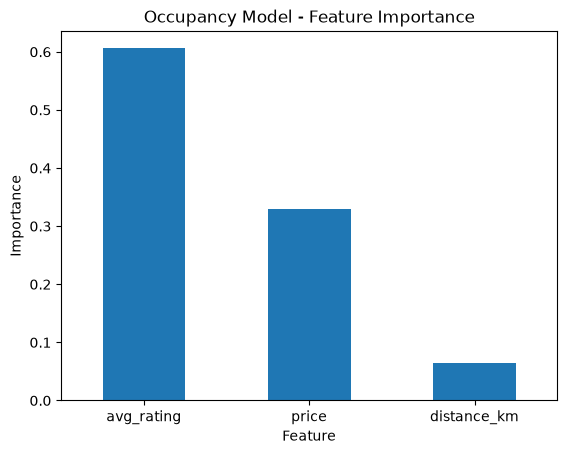

In [8]:
# Feature importance
importance = (
    pd.Series(model.feature_importances_, index=features)
    .sort_values(ascending=False)
)

importance.plot(kind="bar")
plt.title("Occupancy Model - Feature Importance")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.xticks(rotation=0)
plt.show()


In [9]:
# Save the trained occupancy model and the information needed by
# the recommendation notebook.
model_bundle = {
    "model": model,
    "features": features,
    "user_lat": USER_LAT,
    "user_lon": USER_LON
}

joblib.dump(model_bundle, "occupancy_model.joblib")

print("Saved: occupancy_model.joblib")


Saved: occupancy_model.joblib
